# Preparation

1. Load train.csv and test.csv
              ↓
2. Inspect data
   - missing values
   - duplicates
   - distributions
   - skewness
              ↓
3. Train/validation split
              ↓
4. Data cleaning + preprocessing
   - median imputation
   - most-frequent imputation
   - categorical encoding
   - scaling
              ↓
5. Feature engineering
   - FareLog
   - FamilySize
   - IsAlone
   - Title
   - Deck
              ↓
6. Train models
   - Naive Bayes
   - Linear Regression
   - Ridge
   - LASSO
              ↓
7. Evaluate on validation set
              ↓
8. Choose best model
              ↓
9. Retrain best model on ALL train.csv
              ↓
10. Predict test.csv


We calculate preprocessing rules (such as the median for imputation) only from the training data and apply those same rules to the validation data because the validation set should simulate completely new, unseen data; if we calculate its own median, we are allowing the validation data to influence the preprocessing and making our evaluation less fair. 
Imagine tomorrow you receive one new passenger:
Age = NaN

Where would you get the median?
You don't have a new validation dataset containing hundreds of passengers from which you can calculate a new median.
You only have the rules learned from your training data.

So your deployed system has to say:
"If Age is missing, use the median I learned during training."
That is why validation should simulate that situation.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    Binarizer
)

from sklearn.impute import SimpleImputer

from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


In [ ]:
# Configuration

RANDOM_STATE = 42
TEST_SIZE = 0.20

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.float_format",
    lambda x: f"{x:.4f}"
)

In [ ]:
# Load the data

train = pd.read_csv("titanic/train.csv")
test = pd.read_csv("titanic/test.csv")

print("Training shape:", train.shape)
print("Test shape:", test.shape)

print("\nTraining columns:")
print(train.columns.tolist())

print("\nFirst 5 training rows:")
display(train.head())

# TRAIN / VALIDATION SPLIT

In [ ]:
# TRAIN / VALIDATION SPLIT

# Separate target from predictors
X = train.drop(columns=["Survived"])
y = train["Survived"]

# Split the labeled training data
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)

# Data Exploration

In [79]:
# ============================================
# DATA EXPLORATION — TRAINING SET
# ============================================

print("TRAINING SET INFO")
print("=" * 60)
X_train.info()

TRAINING SET INFO
<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    object 
 10  Embarked     710 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 66.8+ KB


In [80]:
# ============================================
# MISSING VALUES — TRAINING SET
# ============================================

missing_train = pd.DataFrame({
    "Missing Count": X_train.isnull().sum(),
    "Missing Percentage": X_train.isnull().mean() * 100
})

display(
    missing_train
    .sort_values("Missing Percentage", ascending=False)
)


,Missing Count,Missing Percentage
Cabin,552,77.5281
Age,137,19.2416
Embarked,2,0.2809
PassengerId,0,0.0000
Pclass,0,0.0000
Name,0,0.0000
Sex,0,0.0000
SibSp,0,0.0000
Parch,0,0.0000
Ticket,0,0.0000


In [75]:
# ============================================
# DUPLICATES — TRAINING SET
# ============================================

print(
    "Number of duplicate rows in training set:",
    X_train.duplicated().sum()
)

Number of duplicate rows in training set: 0


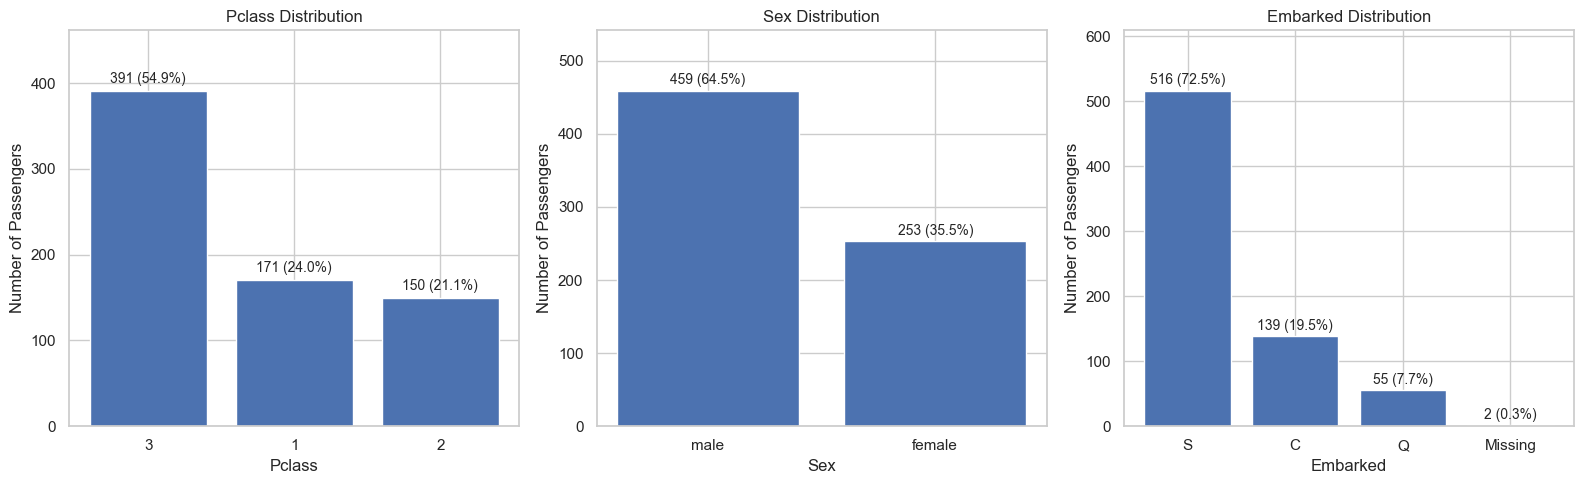

In [82]:
# ============================================
# CATEGORICAL VARIABLES — TRAINING SET
# ============================================

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked"
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5)
)

for ax, column in zip(axes, categorical_features):

    # Counts
    counts = X_train[column].value_counts(dropna=False)

    # Percentages
    percentages = (
        X_train[column]
        .value_counts(dropna=False, normalize=True)
        * 100
    )

    # Convert missing values to a readable label
    labels = [
        "Missing" if pd.isna(value) else str(value)
        for value in counts.index
    ]

    # Plot
    bars = ax.bar(
        labels,
        counts.values
    )

    ax.set_title(f"{column} Distribution")
    ax.set_xlabel(column)
    ax.set_ylabel("Number of Passengers")

    # Add count and percentage to each bar
    for bar, count, percentage in zip(
        bars,
        counts.values,
        percentages.values
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f"{count} ({percentage:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=10
        )

    # Leave room for labels
    ax.set_ylim(
        0,
        max(counts.values) * 1.18
    )

plt.tight_layout()
plt.show()

,Feature,Skewness,Absolute Skewness,Interpretation
1,Fare,4.6462,4.6462,Strongly skewed
2,SibSp,3.8156,3.8156,Strongly skewed
3,Parch,2.8426,2.8426,Strongly skewed
0,Age,0.3533,0.3533,Approximately symmetric


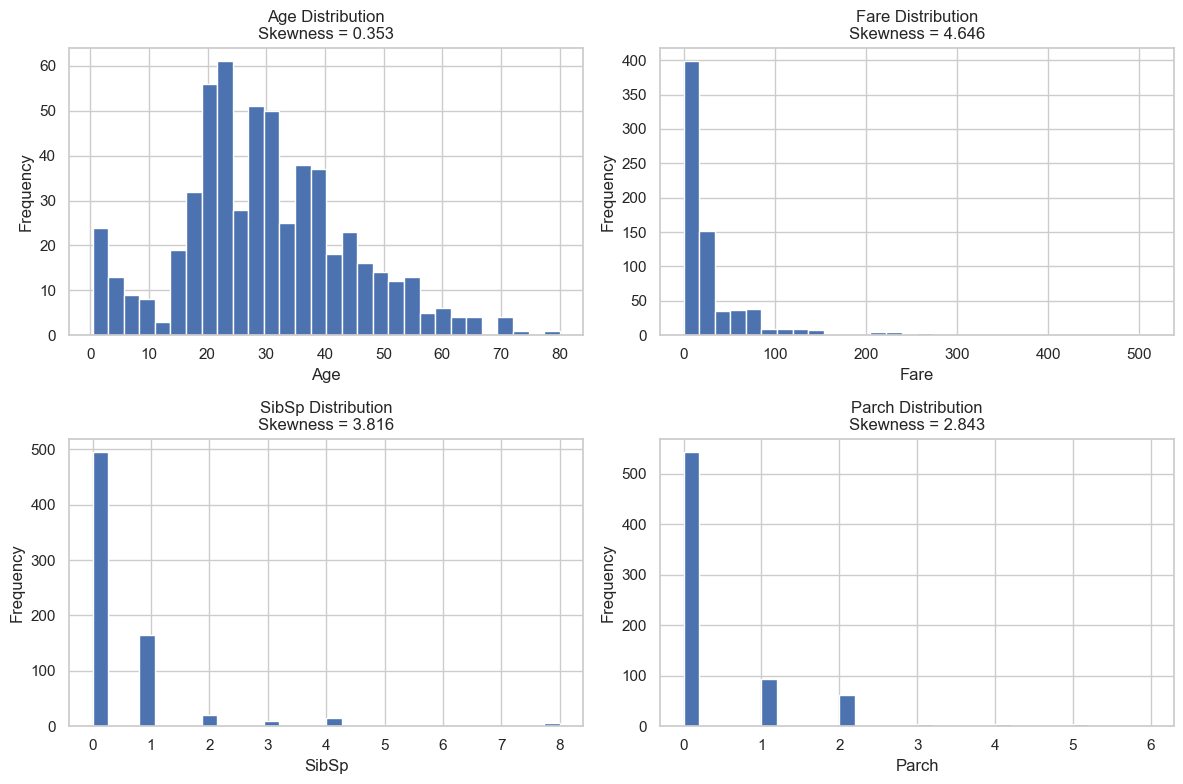

In [84]:
# ============================================
# SKEWNESS — TRAINING SET
# ============================================

numeric_features_to_check = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

# --------------------------------------------
# Calculate skewness
# --------------------------------------------

skewness_results = pd.DataFrame({
    "Feature": numeric_features_to_check,
    "Skewness": [
        X_train[column].skew()
        for column in numeric_features_to_check
    ]
})

skewness_results["Absolute Skewness"] = (
    skewness_results["Skewness"].abs()
)

skewness_results["Interpretation"] = np.where(
    skewness_results["Absolute Skewness"] < 0.5,
    "Approximately symmetric",
    np.where(
        skewness_results["Absolute Skewness"] < 1,
        "Moderately skewed",
        "Strongly skewed"
    )
)

# Display results
display(
    skewness_results.sort_values(
        "Absolute Skewness",
        ascending=False
    )
)

# --------------------------------------------
# Visualize distributions
# --------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

axes = axes.flatten()

for i, column in enumerate(numeric_features_to_check):

    axes[i].hist(
        X_train[column].dropna(),
        bins=30
    )

    skew_value = X_train[column].skew()

    axes[i].set_title(
        f"{column} Distribution\n"
        f"Skewness = {skew_value:.3f}"
    )

    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

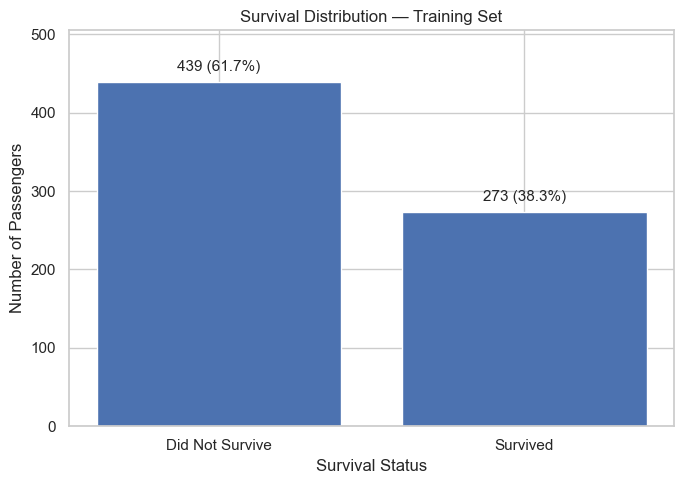

In [85]:
# ============================================
# TARGET DISTRIBUTION — TRAINING SET
# ============================================

survived_counts = y_train.value_counts().sort_index()
survived_percentages = (
    y_train.value_counts(normalize=True)
    .sort_index()
    * 100
)

labels = ["Did Not Survive", "Survived"]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    labels,
    survived_counts.values
)

plt.title("Survival Distribution — Training Set")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

for bar, count, percentage in zip(
    bars,
    survived_counts.values,
    survived_percentages.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{count} ({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.ylim(0, max(survived_counts.values) * 1.15)
plt.tight_layout()
plt.show()

# Data Cleaning and Feature Engineering

In [ ]:
# FEATURE ENGINEERING

def feature_engineer(df):
    df = df.copy()

    # ----------------------------
    # Fare transformation
    # ----------------------------
    df["FareLog"] = np.log1p(df["Fare"])

    # ----------------------------
    # Family features
    # ----------------------------
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    df["IsAlone"] = (
        df["FamilySize"] == 1
    ).astype(int)

    # ----------------------------
    # Title from Name
    # ----------------------------
    df["Title"] = (
        df["Name"]
        .str.extract(r",\s*([^.]*)\.", expand=False)
        .str.strip()
    )

    # Standardize titles
    df["Title"] = df["Title"].replace({
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs"
    })

    # Keep common titles and group the rest
    df["Title"] = df["Title"].where(
        df["Title"].isin([
            "Mr",
            "Miss",
            "Mrs",
            "Master"
        ]),
        "Rare"
    )

    # ----------------------------
    # Deck from Cabin
    # ----------------------------
    df["Deck"] = (
        df["Cabin"]
        .fillna("Unknown")
        .str[0]
    )

    # ----------------------------
    # Cabin known indicator
    # ----------------------------
    df["CabinKnown"] = (
        df["Cabin"].notna()
    ).astype(int)

    # ----------------------------
    # Ticket prefix
    # ----------------------------
    df["TicketPrefix"] = (
        df["Ticket"]
        .str.replace(r"\d", "", regex=True)
        .str.replace(r"[\s./]+", "", regex=True)
        .str.upper()
    )

    df["TicketPrefix"] = df["TicketPrefix"].replace(
        "",
        "NUMERIC"
    )

    return df


X_train_fe = feature_engineer(X_train)
X_val_fe = feature_engineer(X_val)   # Feature engineering that uses fixed rules -> okay on val.

print("Training data after feature engineering:")
print(X_train_fe.shape)

print("\nValidation data after feature engineering:")
print(X_val_fe.shape)

In [86]:
# DATA CLEANING + PREPROCESSING

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --------------------------------------------
# Remove columns that should not be used
# --------------------------------------------

columns_to_drop = [
    "PassengerId",
    "Name",
    "Ticket",
    "Cabin"
]

X_train_model = X_train_fe.drop(columns=columns_to_drop)
X_val_model = X_val_fe.drop(columns=columns_to_drop)

# --------------------------------------------
# Define numerical and categorical features
# --------------------------------------------

numerical_features = [
    "Age",
    "Fare",
    "FareLog",
    "SibSp",
    "Parch",
    "FamilySize",
    "IsAlone",
    "CabinKnown"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title",
    "Deck",
    "TicketPrefix"
]

# --------------------------------------------
# Numerical preprocessing
# --------------------------------------------

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# --------------------------------------------
# Categorical preprocessing
# --------------------------------------------

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# --------------------------------------------
# Combine preprocessing
# --------------------------------------------

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train_model)

# Apply the same preprocessing to validation data
X_val_processed = preprocessor.transform(X_val_model)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)

Processed training shape: (712, 54)
Processed validation shape: (179, 54)
